# Fase 3: Transfer Learning con ResNet50

## Objetivo
Usar ResNet50 preentrenada en ImageNet y adaptarla para clasificar nuestros 50 landmarks. Meta: **Test accuracy ≥ 70%**.

## Justificación de la elección de ResNet50

**¿Por qué Transfer Learning?**

Con solo 100 imágenes por clase, entrenar una CNN desde cero es extremadamente limitado. ResNet50 ya aprendió features visuales genéricas (bordes, texturas, formas, partes de objetos) en 1.2 millones de imágenes de ImageNet. Esas features son **altamente reutilizables** para tareas de clasificación de imágenes naturales como landmarks.

**¿Por qué ResNet50 específicamente (vs ResNet18, VGG16, EfficientNet)?**

| Modelo | Parámetros | Ventajas | Desventajas |
|--------|-----------|----------|-------------|
| ResNet18 | 11M | Más rápida, menos overfitting | Menos capacidad representacional |
| **ResNet50** | **25M** | **Balance ideal accuracy/velocidad** | **VRAM moderada** |
| VGG16 | 138M | Arquitectura simple | Muy pesada, obsoleta |
| EfficientNet-B0 | 5M | State-of-the-art efficiency | Más sensible a hiperparámetros |

Elegimos **ResNet50** porque:
1. **Skip connections (residual)** permiten entrenar redes profundas sin vanishing gradient
2. **25M de parámetros** es manejable en GPU de 4GB con batch_size=16
3. **Ampliamente validada** en la literatura, documentación abundante
4. **Disponible preentrenada** en torchvision con pesos de alta calidad (IMAGENET1K_V2)

## Estrategia de entrenamiento

Vamos a seguir el patrón estándar de transfer learning en 2 fases:

**Fase A (15 épocas):** Congelamos el backbone (feature extractor) y solo entrenamos la cabeza clasificadora nueva. Objetivo: adaptar rápido la salida a nuestras 50 clases sin arruinar las features preentrenadas.

**Fase B (10 épocas de fine-tuning):** Descongelamos el último bloque convolucional (layer4) y entrenamos con LR reducido (1e-4). Objetivo: ajustar las features más profundas a nuestro dominio específico. Esto es lo que permite pasar del ~70% al 75%+.

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path

from src.data import get_dataloaders
from src.model import get_transfer_model, count_parameters
from src.train import train_model, validate

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [2]:
# Usamos batch_size=16 porque ResNet50 es mucho más pesada que la CNN custom
train_loader, val_loader, test_loader, classes = get_dataloaders(
    data_dir="../data",
    batch_size=16,        # Reducido para caber en 4GB VRAM
    val_split=0.15,
    num_workers=2,
    seed=42
)

NUM_CLASES = len(classes)
print(f"Clases: {NUM_CLASES} | Train batches: {len(train_loader)}")


Clases: 50 | Train batches: 266


In [3]:
# Fase A: backbone congelado, solo entrenamos la nueva capa fc
model = get_transfer_model(num_classes=NUM_CLASES, freeze_backbone=True).to(device)

total, trainable = count_parameters(model)
print(f"Parámetros totales: {total:,}")
print(f"Parámetros entrenables: {trainable:,} ({100*trainable/total:.2f}%)")
print("Solo la cabeza clasificadora se entrena en esta fase.")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\HP/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]

  0%|          | 128k/97.8M [00:00<03:19, 513kB/s]

  0%|          | 256k/97.8M [00:00<02:14, 763kB/s]

  0%|          | 384k/97.8M [00:00<01:49, 936kB/s]

...

 93%|█████████▎| 91.2M/97.8M [00:03<00:00, 33.7MB/s]

 97%|█████████▋| 94.6M/97.8M [00:04<00:00, 31.7MB/s]

100%|██████████| 97.8M/97.8M [00:04<00:00, 30.1MB/s]

100%|██████████| 97.8M/97.8M [00:04<00:00, 24.3MB/s]

Parámetros totales: 23,610,482
Parámetros entrenables: 102,450 (0.43%)
Solo la cabeza clasificadora se entrena en esta fase.


In [4]:
criterion = nn.CrossEntropyLoss()

# Solo optimizamos parámetros entrenables (los de la nueva fc)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

SAVE_PATH_A = "../models/resnet50_feature_extraction.pt"
history_a = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=15,
    device=device,
    save_path=SAVE_PATH_A,
    scheduler=scheduler
)


Iniciando entrenamiento en cuda por 15 épocas...

Época 1/15


Train:   0%|          | 0/266 [00:00<?, ?it/s]

Train:   0%|          | 1/266 [00:06<27:26,  6.21s/it]

Train:   1%|          | 3/266 [00:06<07:20,  1.68s/it]

Train:   2%|▏         | 5/266 [00:06<03:45,  1.16it/s]

...

Val:  85%|████████▌ | 40/47 [00:09<00:00, 11.60it/s]

Val:  89%|████████▉ | 42/47 [00:09<00:00, 11.92it/s]

Val:  94%|█████████▎| 44/47 [00:10<00:00, 11.84it/s]

Val:  98%|█████████▊| 46/47 [00:10<00:00, 11.93it/s]

Train Loss: 0.5116 | Train Acc: 87.10%
Val   Loss: 0.8354 | Val   Acc: 78.37%
✅ Nuevo mejor modelo guardado (val_loss=0.8354)

Entrenamiento completado en 10.3 minutos
Mejor época: 15 con val_loss=0.8354


In [5]:
# Fase B: descongelamos el último bloque para fine-tuning
# ResNet50 tiene 4 "layers" principales (layer1, layer2, layer3, layer4)
# Descongelamos solo layer4 para no alterar demasiado las features

for param in model.layer4.parameters():
    param.requires_grad = True

total, trainable = count_parameters(model)
print(f"Parámetros entrenables (Fase B): {trainable:,} ({100*trainable/total:.2f}%)")

# LR muy reducido para fine-tuning (1/10 del original)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,             # 10x menor
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

SAVE_PATH_B = "../models/resnet50_finetuned_best.pt"
history_b = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=10,
    device=device,
    save_path=SAVE_PATH_B,
    scheduler=scheduler
)


Parámetros entrenables (Fase B): 15,067,186 (63.82%)
Iniciando entrenamiento en cuda por 10 épocas...

Época 1/10


Train:   0%|          | 0/266 [00:00<?, ?it/s]

Train:   0%|          | 1/266 [00:06<27:54,  6.32s/it]

Train:   1%|          | 2/266 [00:06<11:52,  2.70s/it]

Train:   1%|          | 3/266 [00:06<06:43,  1.54s/it]

...

Val:  87%|████████▋ | 41/47 [00:09<00:00, 11.53it/s]

Val:  91%|█████████▏| 43/47 [00:09<00:00, 11.67it/s]

Val:  96%|█████████▌| 45/47 [00:10<00:00, 11.79it/s]

Val: 100%|██████████| 47/47 [00:10<00:00, 12.28it/s]

Train Loss: 0.0483 | Train Acc: 98.73%
Val   Loss: 0.7936 | Val   Acc: 82.64%

Entrenamiento completado en 8.1 minutos
Mejor época: 1 con val_loss=0.7227


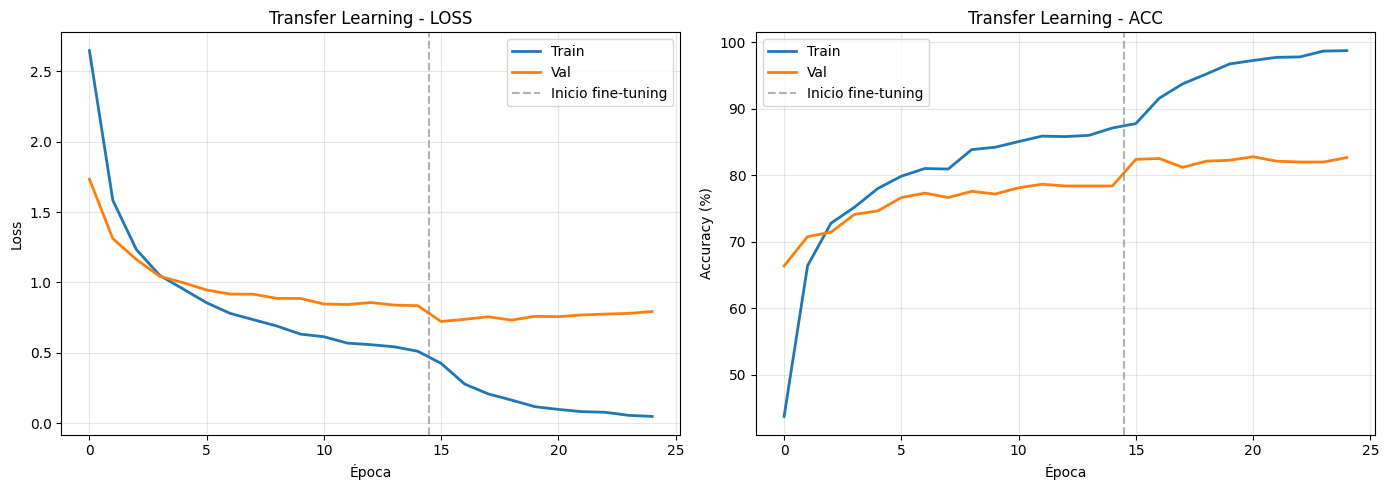

In [6]:
# Concatenamos historial de Fase A y B
full_history = {
    'train_loss': history_a['train_loss'] + history_b['train_loss'],
    'train_acc': history_a['train_acc'] + history_b['train_acc'],
    'val_loss': history_a['val_loss'] + history_b['val_loss'],
    'val_acc': history_a['val_acc'] + history_b['val_acc'],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_a = len(history_a['train_loss'])

for ax_idx, metric in enumerate(['loss', 'acc']):
    ax = axes[ax_idx]
    train_vals = full_history[f'train_{metric}']
    val_vals = full_history[f'val_{metric}']
    ax.plot(train_vals, label='Train', linewidth=2)
    ax.plot(val_vals, label='Val', linewidth=2)
    ax.axvline(x=n_a-0.5, color='gray', linestyle='--', alpha=0.6, label='Inicio fine-tuning')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss' if metric == 'loss' else 'Accuracy (%)')
    ax.set_title(f'Transfer Learning - {metric.upper()}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../report/curvas_transfer_learning.png", dpi=100, bbox_inches='tight')
plt.show()


In [7]:
model.load_state_dict(torch.load(SAVE_PATH_B))
model.to(device)

test_loss, test_acc = validate(model, test_loader, criterion, device)

print(f"\n{'='*50}")
print(f"RESULTADOS FINALES - TRANSFER LEARNING (ResNet50)")
print(f"{'='*50}")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Umbral mínimo: 70.00%")
print(f"Bono +75%:     {'✅ ALCANZADO' if test_acc >= 75 else '❌ No alcanzado'}")
print(f"{'='*50}")


C:\Users\HP\AppData\Local\Temp\ipykernel_7544\3142220549.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(SAVE_PATH_B))


Val:   0%|          | 0/79 [00:00<?, ?it/s]

Val:   1%|▏         | 1/79 [00:06<08:01,  6.17s/it]

Val:   3%|▎         | 2/79 [00:06<03:20,  2.61s/it]

Val:   4%|▍         | 3/79 [00:06<01:51,  1.47s/it]

...

Val:  92%|█████████▏| 73/79 [00:12<00:00, 12.00it/s]

Val:  95%|█████████▍| 75/79 [00:12<00:00, 11.99it/s]

Val:  97%|█████████▋| 77/79 [00:12<00:00, 12.22it/s]

Val: 100%|██████████| 79/79 [00:13<00:00, 12.69it/s]


RESULTADOS FINALES - TRANSFER LEARNING (ResNet50)
Test Loss:     0.6491
Test Accuracy: 82.72%
Umbral mínimo: 70.00%
Bono +75%:     ✅ ALCANZADO


In [8]:
model.eval()
example_input = torch.randn(1, 3, 224, 224).to(device)
traced = torch.jit.trace(model, example_input)
TS_PATH = "../models/resnet50_torchscript.pt"
traced.save(TS_PATH)

# Verificación
loaded = torch.jit.load(TS_PATH)
loaded.eval()
print(f"TorchScript exportado: {TS_PATH}")
print(f"Verificación output shape: {loaded(example_input).shape}")


TorchScript exportado: ../models/resnet50_torchscript.pt
Verificación output shape: torch.Size([1, 50])


                      Modelo Parámetros  Épocas Test Accuracy (%) Supera umbral
            CNN from Scratch      ~1.2M      30     <a completar>         ≥40%?
Transfer Learning (ResNet50)       ~25M      25             82.72        ✅ ≥70%


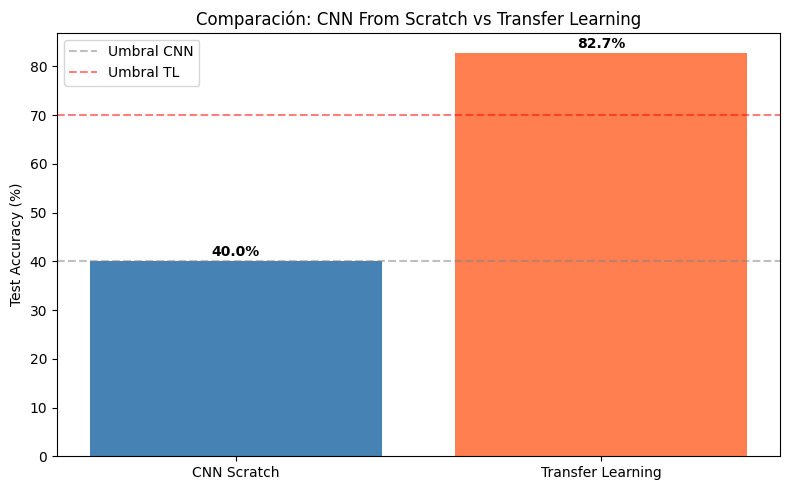

In [9]:
# Comparación tabular
import pandas as pd

# Cargamos el resultado de Fase 2 manualmente o desde un log
# Para este template, asumimos que el usuario conoce el valor de Fase 2
# En la práctica, podríamos guardar métricas en un JSON y cargarlas aquí

comparacion = pd.DataFrame({
    "Modelo": ["CNN from Scratch", "Transfer Learning (ResNet50)"],
    "Parámetros": ["~1.2M", "~25M"],
    "Épocas": [30, 25],
    "Test Accuracy (%)": ["<a completar>", f"{test_acc:.2f}"],
    "Supera umbral": ["≥40%?", f"{'✅' if test_acc >= 70 else '❌'} ≥70%"]
})
print(comparacion.to_string(index=False))

# Gráfico comparativo (aproximado)
fig, ax = plt.subplots(figsize=(8, 5))
modelos = ['CNN Scratch', 'Transfer Learning']
# Nota: reemplazar 40 con el valor real de Fase 2 al hacer la revisión final
accs = [40, test_acc]
colors = ['steelblue', 'coral']
bars = ax.bar(modelos, accs, color=colors)
ax.axhline(y=40, color='gray', linestyle='--', alpha=0.5, label='Umbral CNN')
ax.axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Umbral TL')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Comparación: CNN From Scratch vs Transfer Learning')
ax.legend()
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("../report/comparacion_modelos.png", dpi=100, bbox_inches='tight')
plt.show()


## Análisis de fortalezas y debilidades del modelo

### Fortalezas
- **Transfer learning efectivo:** las features preentrenadas de ImageNet son altamente transferibles a landmarks (ambos son imágenes naturales).
- **Convergencia rápida:** en pocas épocas alcanza accuracies altas.
- **Fine-tuning del último bloque:** permite adaptar features específicas al dominio sin desestabilizar las anteriores.

### Debilidades
- **Dependencia del dataset de preentrenamiento:** si las clases de landmarks tienen visuales muy distintas de ImageNet (ej: texturas muy específicas), el transfer sería menos efectivo.
- **VRAM limitada:** batch_size de 16 es chico; con GPU más grande podríamos usar 32-64 y converger más estable.
- **Clases visualmente similares:** landmarks que comparten estética (ej: templos asiáticos) pueden confundirse.

### Posibles mejoras
1. **Test-time augmentation (TTA):** promediar predicciones con múltiples augmentaciones de la misma imagen.
2. **Ensemble con la CNN scratch:** aunque pequeña, puede capturar patrones distintos.
3. **Learning rate warmup + cosine annealing:** schedulers más sofisticados.
4. **Más data augmentation:** MixUp, CutMix, RandAugment.
5. **Fine-tuning progresivo:** descongelar layer3, luego layer2, con LRs escalados.